In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture

import warnings
warnings.filterwarnings('ignore')

In [2]:
df_causal = pd.read_csv("../dunnhumby_The-Complete-Journey/causal_data.csv")
df_camp_table = pd.read_csv("../dunnhumby_The-Complete-Journey/campaign_table.csv")
df_camp_desc = pd.read_csv("../dunnhumby_The-Complete-Journey/campaign_desc.csv")
df_coupon_red = pd.read_csv("../dunnhumby_The-Complete-Journey/coupon_redempt.csv")
df_coupon = pd.read_csv("../dunnhumby_The-Complete-Journey/coupon.csv")
df_demogr = pd.read_csv("../dunnhumby_The-Complete-Journey/hh_demographic.csv")
df_trxn = pd.read_csv("../dunnhumby_The-Complete-Journey/transaction_data.csv")
df_product = pd.read_csv("../dunnhumby_The-Complete-Journey/product.csv")
df_segmented = pd.read_csv("../dunnhumby_The-Complete-Journey/segmented_df.csv")

**CAMPAIGN TABLE**

`1. df_causal`  
`2. df_camp_table`  
`3. df_camp_desc`  
`4. df_coupon_red `  
`5. df_coupon `  
`6. df_demogr `

In [3]:
df_camp_table.head()

,DESCRIPTION,household_key,CAMPAIGN
0,TypeA,17,26
1,TypeA,27,26
2,TypeA,212,26
3,TypeA,208,26
4,TypeA,192,26


This table shows which campign is associated with a household.

In [4]:
df_camp_table.shape

(7208, 3)

In [5]:
# campaigns per household
tab1 = df_camp_table.groupby('household_key')['CAMPAIGN'].nunique().reset_index()
tab1

,household_key,CAMPAIGN
0,1,8
1,2,1
2,3,3
3,4,1
4,6,4
...,...,...
1579,2496,5
1580,2497,3
1581,2498,6
1582,2499,2


In [6]:
tab2 =df_trxn.groupby('household_key')['BASKET_ID'].nunique().reset_index()

In [7]:
hh_camp_mapping = pd.merge(left = tab2, right=tab1, how='left', on='household_key').fillna(0).drop(columns=['BASKET_ID'])
hh_camp_mapping

,household_key,CAMPAIGN
0,1,8.0
1,2,1.0
2,3,3.0
3,4,1.0
4,5,0.0
...,...,...
2495,2496,5.0
2496,2497,3.0
2497,2498,6.0
2498,2499,2.0


**CAMPAIGN DESCRIPTION TABLE**

In [8]:
df_camp_desc.head()

,DESCRIPTION,CAMPAIGN,START_DAY,END_DAY
0,TypeB,24,659,719
1,TypeC,15,547,708
2,TypeB,25,659,691
3,TypeC,20,615,685
4,TypeB,23,646,684


In [9]:
df_camp_desc.shape

(30, 4)

In [10]:
df_camp_desc['DURATION'] = df_camp_desc['END_DAY'] - df_camp_desc['START_DAY']

In [11]:
df_camp_desc.head()

,DESCRIPTION,CAMPAIGN,START_DAY,END_DAY,DURATION
0,TypeB,24,659,719,60
1,TypeC,15,547,708,161
2,TypeB,25,659,691,32
3,TypeC,20,615,685,70
4,TypeB,23,646,684,38


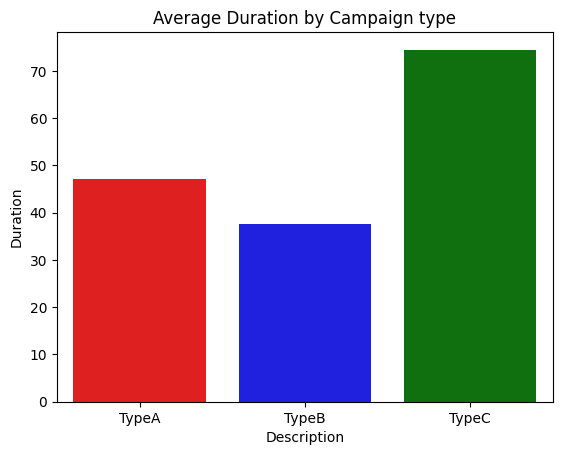

In [12]:
# coupon redemption check
c = ['red','blue','green']
avg_duration_by_campaign_type = df_camp_desc.groupby('DESCRIPTION')['DURATION'].mean().reset_index()
sns.barplot(data = avg_duration_by_campaign_type, x = 'DESCRIPTION', y = 'DURATION', palette = c)
plt.xlabel('Description')
plt.ylabel('Duration')
plt.title('Average Duration by Campaign type')
plt.show()

- Type C has the highest avg. run duration
- Type B has the lowest avg. run duration

**COUPON RELATED TABLES**

In [13]:
df_coupon.head()

,COUPON_UPC,PRODUCT_ID,CAMPAIGN
0,10000089061,27160,4
1,10000089064,27754,9
2,10000089073,28897,12
3,51800009050,28919,28
4,52100000076,28929,25


In [14]:
df_coupon_red.head()

,household_key,DAY,COUPON_UPC,CAMPAIGN
0,1,421,10000085364,8
1,1,421,51700010076,8
2,1,427,54200000033,8
3,1,597,10000085476,18
4,1,597,54200029176,18


In [15]:
df_coupon_red.groupby('household_key')[['COUPON_UPC', 'CAMPAIGN']].nunique().reset_index()

,household_key,COUPON_UPC,CAMPAIGN
0,1,5,2
1,8,1,1
2,13,21,7
3,14,3,1
4,18,8,3
...,...,...,...
429,2488,11,5
430,2489,27,6
431,2494,5,1
432,2496,11,3


**CASUAL TABLE**

In [16]:
df_causal.head()

,PRODUCT_ID,STORE_ID,WEEK_NO,display,mailer
0,26190,286,70,0,A
1,26190,288,70,0,A
2,26190,289,70,0,A
3,26190,292,70,0,A
4,26190,293,70,0,A


In [17]:
df_causal.shape

(36786524, 5)

In [18]:
df_demogr.head()

,classification_1,classification_2,classification_3,HOMEOWNER_DESC,classification_5,classification_4,KID_CATEGORY_DESC,household_key
0,Age Group6,X,Level4,Homeowner,Group5,2,None/Unknown,1
1,Age Group4,X,Level5,Homeowner,Group5,2,None/Unknown,7
2,Age Group2,Y,Level3,Unknown,Group4,3,1,8
3,Age Group2,Y,Level6,Homeowner,Group4,4,2,13
4,Age Group4,Z,Level5,Homeowner,Group3,1,None/Unknown,16


In [19]:
df_coupon_red.head()

,household_key,DAY,COUPON_UPC,CAMPAIGN
0,1,421,10000085364,8
1,1,421,51700010076,8
2,1,427,54200000033,8
3,1,597,10000085476,18
4,1,597,54200029176,18


`1. df_camp_table`  
`2. df_camp_desc`  
`3. df_coupon_red `  
`4. df_coupon `  
`5.df_trxn`  
`6.df_product`  
7. df_demogr  
8. df_causal

We are going to use the highlighted tables for Campaign effectiveness prediction problem.